Nombre: Jhon Cristian Quispe Carita

### **Paso 1: Configuración del Entorno y Carga de Datos**

Primero, importaremos todas las librerías necesarias y cargaremos el dataset `load_wine` de Scikit-learn.

In [ ]:
import numpy as np
from sklearn.datasets import load_wine
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import warnings

# Suprimir advertencias de convergencia, etc.
warnings.filterwarnings('ignore')

# Cargar el dataset de vinos
data = load_wine()
X, y = data.data, data.target

print(f"Dataset cargado: {X.shape[0]} muestras, {X.shape[1]} características.")
print(f"Clases: {np.unique(y)}")

Dataset cargado: 178 muestras, 13 características.
Clases: [0 1 2]


### **Paso 2: Definición de Hiperparámetros y Rangos**

Definimos los rangos para cada uno de los 5 hiperparámetros que el algoritmo PSO intentará optimizar. También definimos los parámetros clave para el algoritmo PSO (factores de inercia, cognitivo y social, número de partículas e iteraciones).

In [ ]:
# Rangos de los hiperparámetros (min, max) y su tipo
# Orden: n_estimators, max_depth, min_samples_split, min_samples_leaf, max_features
param_bounds = {
    'n_estimators': {'min': 10, 'max': 200, 'type': 'int'},
    'max_depth': {'min': 1, 'max': 20, 'type': 'int'},
    'min_samples_split': {'min': 2, 'max': 10, 'type': 'int'},
    'min_samples_leaf': {'min': 1, 'max': 10, 'type': 'int'},
    'max_features': {'min': 0.1, 'max': 0.9, 'type': 'float'}
}

# Parámetros del algoritmo PSO
w = 0.5   # Factor de inercia
c1 = 2    # Componente cognitivo (atracción al mejor personal)
c2 = 2    # Componente social (atracción al mejor global)
num_particles = 20 # Número de partículas en el enjambre
num_iterations = 20 # Número de iteraciones del algoritmo

### **Paso 3: Función de Aptitud (Fitness Function)**

Esta función evaluará un conjunto de hiperparámetros. Recibe un vector de 5 dimensiones (los 5 hiperparámetros), entrena un `RandomForestClassifier` y calcula el `accuracy` promedio usando validación cruzada con 3 folds. El objetivo del PSO es maximizar este `accuracy`.

In [ ]:
def fitness_function(params, X, y):
    """
    Calcula la aptitud (accuracy promedio) de un conjunto de hiperparámetros
    para un RandomForestClassifier usando validación cruzada.

    Args:
        params (np.array): Array de 5 elementos [n_estimators, max_depth,
                           min_samples_split, min_samples_leaf, max_features].
        X (np.array): Características del dataset.
        y (np.array): Etiquetas del dataset.

    Returns:
        float: El accuracy promedio de la validación cruzada.
    """
    # Asegurarse de que los hiperparámetros enteros sean de tipo int
    n_estimators = int(params[0])
    max_depth = int(params[1]) if params[1] >= 1 else 1 # max_depth must be >= 1
    min_samples_split = int(params[2]) if params[2] >= 2 else 2 # min_samples_split must be >= 2
    min_samples_leaf = int(params[3]) if params[3] >= 1 else 1 # min_samples_leaf must be >= 1
    max_features = params[4] # max_features es un flotante entre 0.1 y 0.9

    # Crear el modelo RandomForestClassifier con los hiperparámetros dados
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42 # Para reproducibilidad
    )

    # Realizar validación cruzada (3-fold StratifiedKFold para clasificación)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

    return np.mean(scores)

### **Paso 4: Clase `Particle`**

Esta clase representa una partícula en el enjambre. Cada partícula tiene una posición (un conjunto de hiperparámetros), una velocidad, su mejor posición personal (`pbest_pos`) y su mejor aptitud personal (`pbest_fitness`). Los métodos `update_velocity` y `update_position` implementan las ecuaciones centrales del PSO, incluyendo la restricción de los límites de los hiperparámetros.

In [ ]:
class Particle:
    def __init__(self, bounds):
        self.position = np.array([
            np.random.uniform(bounds['n_estimators']['min'], bounds['n_estimators']['max']),
            np.random.uniform(bounds['max_depth']['min'], bounds['max_depth']['max']),
            np.random.uniform(bounds['min_samples_split']['min'], bounds['min_samples_split']['max']),
            np.random.uniform(bounds['min_samples_leaf']['min'], bounds['min_samples_leaf']['max']),
            np.random.uniform(bounds['max_features']['min'], bounds['max_features']['max'])
        ])
        # Inicializar velocidad aleatoriamente en un rango pequeño
        self.velocity = np.random.uniform(-1, 1, size=len(bounds))

        self.pbest_pos = self.position.copy()
        self.pbest_fitness = -np.inf # Inicializar con un valor muy bajo para maximización

    def update_velocity(self, gbest_pos):
        r1 = np.random.rand(len(self.position))
        r2 = np.random.rand(len(self.position))

        cognitive_component = c1 * r1 * (self.pbest_pos - self.position)
        social_component = c2 * r2 * (gbest_pos - self.position)

        self.velocity = w * self.velocity + cognitive_component + social_component

    def update_position(self, bounds):
        self.position = self.position + self.velocity

        # Aplicar límites y asegurarse de que los tipos sean correctos
        for i, (param_name, bound_info) in enumerate(bounds.items()):
            min_val = bound_info['min']
            max_val = bound_info['max']
            param_type = bound_info['type']

            # Restringir la posición dentro de los límites
            self.position[i] = np.clip(self.position[i], min_val, max_val)

            # Asegurarse de que los parámetros enteros sean enteros
            if param_type == 'int':
                self.position[i] = round(self.position[i])


### **Paso 5: Ciclo Principal de PSO**

Aquí se implementa el algoritmo PSO. Inicializamos el enjambre de partículas, cada una con una posición aleatoria dentro de los límites de los hiperparámetros. Luego, en cada iteración:

1.  **Evaluación**: Calculamos la aptitud de cada partícula.
2.  **Actualización Personal (pbest)**: Si la aptitud actual de una partícula es mejor que su `pbest_fitness` anterior, actualizamos su `pbest_pos` y `pbest_fitness`.
3.  **Actualización Global (gbest)**: Si la aptitud actual de una partícula es mejor que el `gbest_fitness` del enjambre, actualizamos el `gbest_pos` y `gbest_fitness`.
4.  **Movimiento de Partículas**: Cada partícula actualiza su velocidad y posición basándose en su `pbest_pos` y el `gbest_pos`.

Este proceso se repite por un número definido de iteraciones, buscando converger hacia un óptimo global.

In [ ]:
# Inicialización del mejor global
gbest_fitness = -np.inf
gbest_pos = None

# Lista para almacenar el historial de accuracy global
accuracy_history = []

# Inicialización del enjambre de partículas
swarm = [Particle(param_bounds) for _ in range(num_particles)]

print("\nIniciando optimización PSO...")

# Bucle principal de PSO
for i in range(num_iterations):
    for particle in swarm:
        # Evaluar la aptitud de la partícula
        current_fitness = fitness_function(particle.position, X, y)

        # Actualizar el mejor personal de la partícula
        if current_fitness > particle.pbest_fitness:
            particle.pbest_fitness = current_fitness
            particle.pbest_pos = particle.position.copy()

        # Actualizar el mejor global del enjambre
        if current_fitness > gbest_fitness:
            gbest_fitness = current_fitness
            gbest_pos = particle.position.copy()

    # Actualizar la velocidad y posición de todas las partículas
    for particle in swarm:
        particle.update_velocity(gbest_pos)
        particle.update_position(param_bounds)

    # Almacenar el mejor accuracy global de esta iteración
    accuracy_history.append(gbest_fitness)

    # Mostrar progreso
    print(f"Iteración {i+1:2d}: Mejor Accuracy = {gbest_fitness:.4f}")

print("\nOptimización PSO finalizada.")


Iniciando optimización PSO...
Iteración  1: Mejor Accuracy = 0.9888
Iteración  2: Mejor Accuracy = 0.9888
Iteración  3: Mejor Accuracy = 0.9888
Iteración  4: Mejor Accuracy = 0.9888
Iteración  5: Mejor Accuracy = 0.9888
Iteración  6: Mejor Accuracy = 0.9888
Iteración  7: Mejor Accuracy = 0.9888
Iteración  8: Mejor Accuracy = 0.9888
Iteración  9: Mejor Accuracy = 0.9888
Iteración 10: Mejor Accuracy = 0.9888
Iteración 11: Mejor Accuracy = 0.9888
Iteración 12: Mejor Accuracy = 0.9888
Iteración 13: Mejor Accuracy = 0.9888
Iteración 14: Mejor Accuracy = 0.9888
Iteración 15: Mejor Accuracy = 0.9888
Iteración 16: Mejor Accuracy = 0.9888
Iteración 17: Mejor Accuracy = 0.9888
Iteración 18: Mejor Accuracy = 0.9888
Iteración 19: Mejor Accuracy = 0.9888
Iteración 20: Mejor Accuracy = 0.9888

Optimización PSO finalizada.


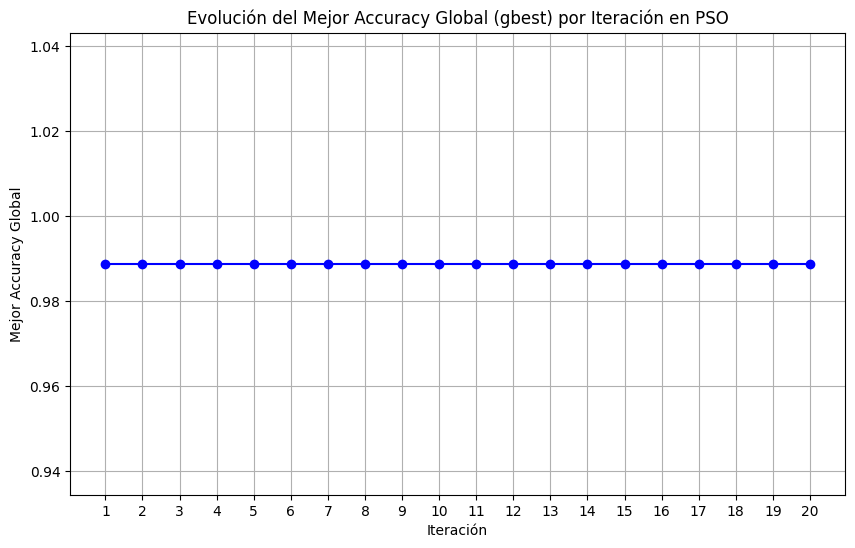

In [ ]:
import matplotlib.pyplot as plt

# Crear la gráfica de la evolución del accuracy
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_iterations + 1), accuracy_history, marker='o', linestyle='-', color='b')
plt.title('Evolución del Mejor Accuracy Global (gbest) por Iteración en PSO')
plt.xlabel('Iteración')
plt.ylabel('Mejor Accuracy Global')
plt.grid(True)
plt.xticks(range(1, num_iterations + 1))
plt.show()

### **Paso 6: Resultados Finales**

Después de todas las iteraciones, imprimimos los mejores hiperparámetros encontrados y el `accuracy` final que se logró con ellos. Es importante recordar que `n_estimators`, `max_depth`, `min_samples_split`, y `min_samples_leaf` deben ser enteros.

In [ ]:
print("\nResultados del Hyperparameter Tuning con PSO:")

# Asegurarse de que los parámetros enteros se muestren como enteros
final_n_estimators = int(gbest_pos[0])
final_max_depth = int(gbest_pos[1])
final_min_samples_split = int(gbest_pos[2])
final_min_samples_leaf = int(gbest_pos[3])
final_max_features = gbest_pos[4]

print(f"Mejores Hiperparámetros Encontrados:")
print(f"  n_estimators: {final_n_estimators}")
print(f"  max_depth: {final_max_depth}")
print(f"  min_samples_split: {final_min_samples_split}")
print(f"  min_samples_leaf: {final_min_samples_leaf}")
print(f"  max_features: {final_max_features:.3f}")
print(f"Accuracy Final Obtenido: {gbest_fitness:.4f}")


Resultados del Hyperparameter Tuning con PSO:
Mejores Hiperparámetros Encontrados:
  n_estimators: 61
  max_depth: 20
  min_samples_split: 6
  min_samples_leaf: 1
  max_features: 0.100
Accuracy Final Obtenido: 0.9888
